In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import regressiontree from sklearn
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

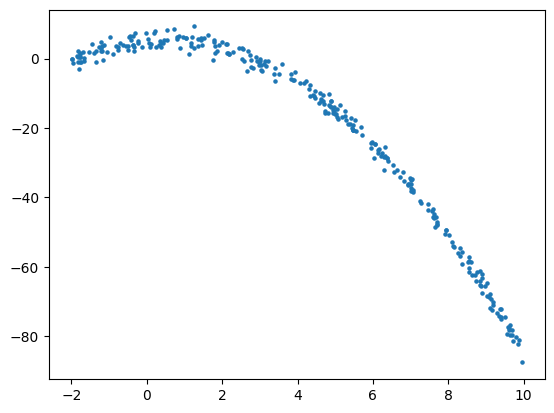

In [2]:
# Dummy Data
def f(x):
    mu, sigma = 0, 1.5
    return -x**2 + x + 5 + np.random.normal(mu, sigma, 1)

num_points = 300
np.random.seed(1)
    
x = np.random.uniform(-2, 10, num_points)
y = np.array( [f(i) for i in x] )

df = pd.DataFrame({'x': x, 'y': y.ravel()})


plt.scatter(x, y, s = 5)

In [3]:
#train test split
df_train, df_test = train_test_split(df, test_size = 0.2)

In [4]:
df2 = df.copy()

In [5]:
row1 = df.iloc[0]

In [6]:
row1

x    3.004264
y   -0.657334
Name: 0, dtype: float64

In [7]:
df['y'].name

'y'

In [8]:
from regressionTree import RegressionTree

In [9]:
tree = RegressionTree(max_depth=7, min_samples_split=5)

In [10]:
tree.fit(df[['x']], df['y'])

In [11]:
#plot predictions and original data
x_test = np.linspace(-2, 5, 100)
y_pred = tree.predict(pd.DataFrame({'x': x_test}))

df_test = pd.DataFrame({'x': x_test, 'y_pred': y_pred})

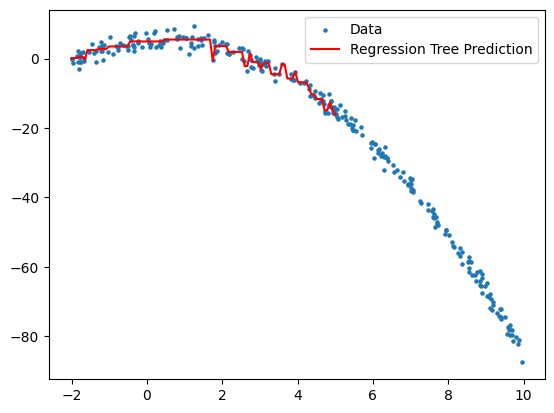

In [12]:
plt.scatter(x, y, s = 5, label='Data')
plt.plot(x_test, y_pred, color='red', label='Regression Tree Prediction')
plt.legend()
plt.show()

In [13]:
tree_sklearn = DecisionTreeRegressor(max_depth=7, min_samples_split=5, random_state=None, criterion='friedman_mse')
tree_sklearn.fit(df2[['x']], df2['y'])
y_pred_sklearn = tree_sklearn.predict(df2[['x']])
df_sklearn = pd.DataFrame({'x': df2['x'], 'y_pred_sklearn': y_pred_sklearn})
df_sklearn.sort_values(by='x', inplace=True)

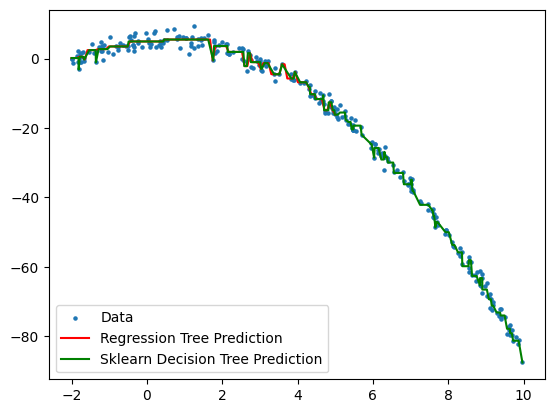

In [14]:
plt.scatter(x, y, s = 5, label='Data')
plt.plot(x_test, y_pred, color='red', label='Regression Tree Prediction')
plt.plot(df_sklearn['x'], df_sklearn['y_pred_sklearn'], color='green', label='Sklearn Decision Tree Prediction')
plt.legend()
plt.show()

In [15]:
tree_train_test = RegressionTree(max_depth=7, min_samples_split=5)

In [16]:
tree_train_test.fit(df_train[['x']], df_train['y'])

In [17]:
test_predictions = tree_train_test.predict(df_test[['x']])

In [18]:
sklearn_tree_train_test = DecisionTreeRegressor(max_depth=7, min_samples_split=5, random_state=None, criterion='friedman_mse')
sklearn_tree_train_test.fit(df_train[['x']], df_train['y'])

,criterion,'friedman_mse'
,splitter,'best'
,max_depth,7
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [19]:
test_predictions_sklearn = sklearn_tree_train_test.predict(df_test[['x']])

In [22]:
#improt cross val score from sklearn
from cross_validation import custom_cross_validate

cv_results = custom_cross_validate(RegressionTree, df, "y", k=5, model_params={'max_depth':7, 'min_samples_split':5})

Starte 5-Fold CV mit erweitertem Reporting...
Fold 1/5 | Test RMSE: 2.07 | Train RMSE: 1.11
Fold 2/5 | Test RMSE: 1.94 | Train RMSE: 1.11
Fold 3/5 | Test RMSE: 2.00 | Train RMSE: 1.11
Fold 4/5 | Test RMSE: 1.83 | Train RMSE: 1.08
Fold 5/5 | Test RMSE: 1.78 | Train RMSE: 1.15
